<a href="https://colab.research.google.com/github/padhma4782/AI-ML-Practice-sheets/blob/main/Guvi_Zen_DS_Session_23_24_datacleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Handling Missing Values**

Handling missing data is an important aspect of data preprocessing in machine learning and data analysis. Missing data can arise for various reasons, and it's crucial to deal with it appropriately to avoid biased or inaccurate results. Here are common techniques for handling missing data:



*   Identify Missing Data : First, identify and understand the extent of missing data in your dataset. Use summary statistics or visualization tools to spot missing values.

*   Remove Missing Data: The simplest approach is to remove rows or columns with missing data. This can be done using functions like dropna in libraries such as Pandas.

import pandas as pd

df.dropna()  # Remove rows with missing data

df.dropna(axis=1)  # Remove columns with missing data


*   Imputation: Imputation involves filling in missing values with estimated or calculated values. Common imputation methods include:
  *   Mean, Median, or Mode Imputation: Fill missing values with the mean, median, or mode of the non-missing values in the same column.

  *   Constant Value Imputation: Replace missing values with a specific constant.

  *   Regression Imputation: Use regression models to predict missing values based on other features.

  *   K-Nearest Neighbors (KNN) Imputation: Replace missing values with values from the K-nearest neighbors in the dataset.

*   Forward Fill and Backward Fill: In time-series / Numerical data, you can use forward fill (fill missing values with the previous value) or backward fill (fill missing values with the next value) when the order of data points matters.

*   Interpolation: Interpolation is useful when missing data follows a pattern. Linear interpolation estimates missing values based on the values before and after the missing data point.
*   Advanced Techniques: For more complex situations, consider using machine learning techniques to predict missing values. Techniques like decision trees, random forests, or deep learning can be employed to impute missing data.

*   Domain-Specific Imputation: Sometimes, domain-specific knowledge can guide the imputation process. For example, in a healthcare dataset, you might have domain knowledge to impute missing blood pressure readings.

*   Feature Engineering: Consider creating new features that explicitly capture the presence or absence of missing data, which can help your model learn from missing data patterns.



In [ ]:
#Mean, Median, or Mode Imputation:
#Replace missing values with the mean (average), median, or mode of the non-missing values in the same column. This is a simple and quick method.
#Suitable for numerical features with a normal or symmetric distribution.

import pandas as pd

# Sample dataset with missing values
data = {
    'Age': [25, 30, 35, None, 40, 45, 50, None, 55, 60],
    'Salary': [50000, None, 60000, 75000, 80000, None, 90000, 100000, None, 120000]
}

df = pd.DataFrame(data)

# Impute missing values with mean, median, and mode
mean_age = df['Age'].mean()
median_salary = df['Salary'].median()
mode_salary = df['Salary'].mode()[0]  # Mode may return multiple values, so we choose the first one

df['Age'].fillna(mean_age, inplace=True)
df['Salary'].fillna(median_salary, inplace=True)

# Display the dataframe after imputation
print(df)


    Age    Salary
0  25.0   50000.0
1  30.0   80000.0
2  35.0   60000.0
3  42.5   75000.0
4  40.0   80000.0
5  45.0   80000.0
6  50.0   90000.0
7  42.5  100000.0
8  55.0   80000.0
9  60.0  120000.0


In [ ]:
# Constant value imputation involves filling missing values with a specific constant,
# often zero or another predetermined value.

import pandas as pd

# Sample dataset with missing values
data = {
    'Age': [25, None, 35, None, 40, 45, None, None, 55, 60],
    'Score': [80, 90, 75, None, 85, 92, 88, None, 78, None]
}

df = pd.DataFrame(data)

# Impute missing values with a constant value (e.g., 0)
constant_value = 0

# Fill missing values in the 'Age' and 'Score' columns with the constant value
df['Age'].fillna(constant_value, inplace=True)
df['Score'].fillna(constant_value, inplace=True)

# Display the dataframe after imputation
print(df)


    Age  Score
0  25.0   80.0
1   0.0   90.0
2  35.0   75.0
3   0.0    0.0
4  40.0   85.0
5  45.0   92.0
6   0.0   88.0
7   0.0    0.0
8  55.0   78.0
9  60.0    0.0


In [ ]:
# Linear interpolation is a method for estimating missing values based on the values before and after
#the missing data point, assuming a linear relationship between the available data points.

import pandas as pd

# Sample dataset with missing values
data = {
    'Year': [2000, 2002, 2004, None, 2008, None, 2012, 2014, None, 2018],
    'Value': [10, 12, None, 18, None, 24, 28, 30, None, 36]
}

df = pd.DataFrame(data)

# Linear interpolation for missing values
df['Year'].interpolate(method='linear', inplace=True)
df['Value'].interpolate(method='linear', inplace=True)

# Display the dataframe after interpolation
print(df)


     Year  Value
0  2000.0   10.0
1  2002.0   12.0
2  2004.0   15.0
3  2006.0   18.0
4  2008.0   21.0
5  2010.0   24.0
6  2012.0   28.0
7  2014.0   30.0
8  2016.0   33.0
9  2018.0   36.0


**Univariate feature imputation**

The SimpleImputer class provides basic strategies for imputing missing values. Missing values can be imputed with a provided constant value, or using the statistics (mean, median or most frequent) of each column in which the missing values are located. This class also allows for different missing values encodings.

The following snippet demonstrates how to replace missing values, encoded as np.nan, using the mean value of the columns (axis 0) that contain the missing values:

In [ ]:
import numpy as np
from sklearn.impute import SimpleImputer
imp = SimpleImputer(missing_values=np.nan, strategy='mean')
imp.fit([[1, 2], [np.nan, 3], [7, 6]])
X = [[np.nan, 2], [6, np.nan], [7, 6]]
print(imp.transform(X))

[[4.         2.        ]
 [6.         3.66666667]
 [7.         6.        ]]


In [ ]:
import scipy.sparse as sp
X = sp.csc_matrix([[1, 2], [0, -1], [8, 8]])
#X is created using the sp.csc_matrix constructor, representing a 3x2 sparse matrix.
#The matrix contains some missing values, which are represented by -1.
imp = SimpleImputer(missing_values=-1, strategy='mean')
#Specify that you want to impute values equal to -1 using the strategy of taking the mean of non-missing values.
imp.fit(X)
X_test = sp.csc_matrix([[-1, 2], [6, -1], [7, 6]])
print(imp.transform(X_test).toarray())

[[3. 2.]
 [6. 5.]
 [7. 6.]]


In [ ]:
import pandas as pd
df = pd.DataFrame([["a", "x"],
                   [np.nan, "y"],
                   ["a", np.nan],
                   ["b", "y"]], dtype="category")
imp = SimpleImputer(strategy="most_frequent")
print(imp.fit_transform(df))

[['a' 'x']
 ['a' 'y']
 ['a' 'y']
 ['b' 'y']]


**Multivariate feature imputation**

A more sophisticated approach is to use the IterativeImputer class, which models each feature with missing values as a function of other features, and uses that estimate for imputation. It does so in an iterated round-robin fashion: at each step, a feature column is designated as output y and the other feature columns are treated as inputs X. A regressor is fit on (X, y) for known y. Then, the regressor is used to predict the missing values of y. This is done for each feature in an iterative fashion, and then is repeated for max_iter imputation rounds. The results of the final imputation round are returned.



In [ ]:
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
imp = IterativeImputer(max_iter=5, random_state=0)
imp.fit([[1, 2], [3, 6], [4, 8], [np.nan, 3], [7, np.nan]])
X_test = [[np.nan, 2], [6, np.nan], [np.nan, 6]]
# the model learns that the second feature is double the first
print(np.round(imp.transform(X_test)))

[[ 1.  2.]
 [ 6. 12.]
 [ 3.  6.]]


**Nearest neighbors imputation**

The KNNImputer class provides imputation for filling in missing values using the k-Nearest Neighbors approach. By default, a euclidean distance metric that supports missing values, nan_euclidean_distances, is used to find the nearest neighbors. Each missing feature is imputed using values from n_neighbors nearest neighbors that have a value for the feature. The feature of the neighbors are averaged uniformly or weighted by distance to each neighbor. If a sample has more than one feature missing, then the neighbors for that sample can be different depending on the particular feature being imputed. When the number of available neighbors is less than n_neighbors and there are no defined distances to the training set, the training set average for that feature is used during imputation. If there is at least one neighbor with a defined distance, the weighted or unweighted average of the remaining neighbors will be used during imputation. If a feature is always missing in training, it is removed during transform.

In [ ]:
import numpy as np
from sklearn.impute import KNNImputer
nan = np.nan
X = [[1, 2, nan], [3, 4, 3], [nan, 6, 5], [8, 8, 7],[3,4,6],[6,8,4],[2,5,4]]
imputer = KNNImputer(n_neighbors=3, weights="uniform")
imputer.fit_transform(X)

array([[1.        , 2.        , 4.33333333],
       [3.        , 4.        , 3.        ],
       [3.66666667, 6.        , 5.        ],
       [8.        , 8.        , 7.        ],
       [3.        , 4.        , 6.        ],
       [6.        , 8.        , 4.        ],
       [2.        , 5.        , 4.        ]])

**Marking imputed values**

The MissingIndicator transformer is useful to transform a dataset into corresponding binary matrix indicating the presence of missing values in the dataset. This transformation is useful in conjunction with imputation. When using imputation, preserving the information about which values had been missing can be informative. Note that both the SimpleImputer and IterativeImputer have the boolean parameter add_indicator (False by default) which when set to True provides a convenient way of stacking the output of the MissingIndicator transformer with the output of the imputer.

In [ ]:
from sklearn.impute import MissingIndicator
X = np.array([[-1, -1, 1, 3],
              [4, -1, 0, -1],
              [8, -1, 1, 0]])
indicator = MissingIndicator(missing_values=-1,features="all")
mask_missing_values_only = indicator.fit_transform(X)
mask_missing_values_only

array([[ True,  True, False, False],
       [False,  True, False,  True],
       [False,  True, False, False]])

**Encoding Data**

Encoding data is a crucial step in preparing categorical data for machine learning models. It involves converting categorical variables into numerical representations that can be used by algorithms.

In [ ]:
# Label encoding is a method for converting categorical data into numerical form by assigning a unique integer to each category

from sklearn.preprocessing import LabelEncoder

# Sample data with categorical labels
data = ['cat', 'dog', 'bird', 'dog', 'cat']

# Create a LabelEncoder instance
label_encoder = LabelEncoder()

# Fit and transform the data to perform label encoding
encoded_data = label_encoder.fit_transform(data)

# Print the original data and the encoded data
print("Original Data:", data)
print("Encoded Data:", encoded_data)

# Inverse transform to get the original labels back
decoded_data = label_encoder.inverse_transform(encoded_data)
print("Decoded Data:", decoded_data)


Original Data: ['cat', 'dog', 'bird', 'dog', 'cat']
Encoded Data: [1 2 0 2 1]
Decoded Data: ['cat' 'dog' 'bird' 'dog' 'cat']


In [ ]:
# One-hot encoding is a technique used to convert categorical data into binary format.
#It creates binary columns for each category,
#where each column indicates the presence or absence of that category.

import pandas as pd

# Sample data with categorical labels
data = {'Color': ['Red', 'Green', 'Blue', 'Green', 'Red']}
df = pd.DataFrame(data)

# Perform one-hot encoding using pandas
one_hot = pd.get_dummies(df, columns=['Color'])

# Print the one-hot encoded DataFrame
print(one_hot)


   Color_Blue  Color_Green  Color_Red
0       False        False       True
1       False         True      False
2        True        False      False
3       False         True      False
4       False        False       True


In [ ]:
# prompt: give example of one hot encoding where only one category is present in one vector

# Create a DataFrame with a single categorical column
df = pd.DataFrame({'Color': ['Red', 'Green', 'Blue']})

# Perform one-hot encoding
one_hot = pd.get_dummies(df, columns=['Color'])

# Print the one-hot encoded DataFrame
print(one_hot)


   Color_Blue  Color_Green  Color_Red
0       False        False       True
1       False         True      False
2        True        False      False


In [ ]:
import pandas as pd

# Sample data with multiple categorical columns
data = {
    'Color': ['Red', 'Green', 'Blue', 'Green', 'Red'],
    'Size': ['Small', 'Large', 'Medium', 'Large', 'Small'],
    'Shape': ['Circle', 'Rectangle', 'Triangle', 'Rectangle', 'Circle']
}

df = pd.DataFrame(data)

# Perform one-hot encoding on all categorical columns
one_hot = pd.get_dummies(df, columns=['Color', 'Size', 'Shape'])

# Print the one-hot encoded DataFrame
print(one_hot)


   Color_Blue  Color_Green  Color_Red  Size_Large  Size_Medium  Size_Small  \
0       False        False       True       False        False        True   
1       False         True      False        True        False       False   
2        True        False      False       False         True       False   
3       False         True      False        True        False       False   
4       False        False       True       False        False        True   

   Shape_Circle  Shape_Rectangle  Shape_Triangle  
0          True            False           False  
1         False             True           False  
2         False            False            True  
3         False             True           False  
4          True            False           False  


In [ ]:
# Ordinal encoding is used when you have categorical data with a clear order or hierarchy among the categories.
#This method assigns numerical values to the categories based on their order.

import pandas as pd

# Sample data with an ordinal column
data = {
    'Size': ['Small', 'Medium', 'Large', 'Medium', 'Small', 'Extra-Large']
}

df = pd.DataFrame(data)

# Define the order of the categories
size_order = ['Small', 'Medium', 'Large', 'Extra-Large']

# Perform ordinal encoding using a custom mapping
df['Size_Encoded'] = df['Size'].apply(lambda x: size_order.index(x))

# Print the original and encoded data
print(df)

          Size  Size_Encoded
0        Small             0
1       Medium             1
2        Large             2
3       Medium             1
4        Small             0
5  Extra-Large             3


In [ ]:
# Binary encoding is a technique used to convert categorical data into binary format.
# Each integer is converted into binary, and separate columns are created for each bit.

!pip install category-encoders

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.9/81.9 kB 2.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import category_encoders as ce

# Sample data with a categorical column
data = {
    'Color': ['Red', 'Green', 'Blue', 'Green', 'Red' , 'Blue']
}

df = pd.DataFrame(data)

# Create a BinaryEncoder instance
encoder = ce.BinaryEncoder(cols=['Color'])

# Perform binary encoding
encoded_data = encoder.fit_transform(df)

# Print the encoded DataFrame
print(encoded_data)


   Color_0  Color_1
0        0        1
1        1        0
2        1        1
3        1        0
4        0        1
5        1        1


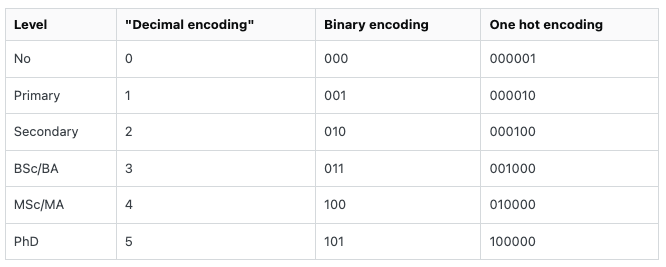

In [ ]:
# Target Encoding : Target encoding, also known as mean encoding,
#is a technique used to encode categorical variables by replacing
#each category with the mean of the target variable for that category. It is often used in classification tasks
#where the target variable is binary or a probability score.
import pandas as pd

# Sample data with categorical and target variables
data = {
    'Category': ['A', 'B', 'A', 'C', 'B', 'C'],
    'Target': [1/2, 1/4, 1/2, 1/4, 1/4, 1/4]
}

df = pd.DataFrame(data)

# Calculate the mean target value for each category
mean_encoding = df.groupby('Category')['Target'].mean()
df['Category_Mean'] = df['Category'].map(mean_encoding)

# Print the original and target-encoded data
print(df)


  Category  Target  Category_Mean
0        A    0.50           0.50
1        B    0.25           0.25
2        A    0.50           0.50
3        C    0.25           0.25
4        B    0.25           0.25
5        C    0.25           0.25


**Outliers**

Outliers are data points that significantly deviate from the majority of data in a dataset. They can introduce noise and bias into statistical analyses and machine learning models. Outlier detection and correction are crucial steps in data preprocessing.

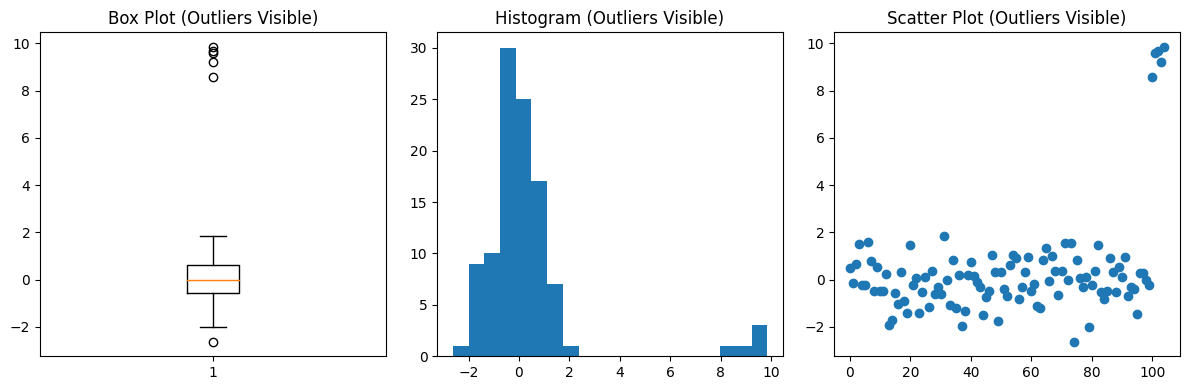

In [ ]:
#Visual Inspection: Start by plotting your data using box plots, histograms, or scatter plots.
#Outliers can sometimes be visually identified.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generate synthetic data with outliers
np.random.seed(42)

# Normally distributed data with outliers
data = np.random.normal(0, 1, 100)
outliers = np.random.normal(10, 1, 5)

# Combine the data with outliers
data = np.concatenate((data, outliers))

# Create a DataFrame
df = pd.DataFrame({'Data': data})

# Plot box plot
plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.boxplot(df['Data'])
plt.title('Box Plot (Outliers Visible)')

# Plot histogram
plt.subplot(132)
plt.hist(df['Data'], bins=20)
plt.title('Histogram (Outliers Visible)')

# Create a scatter plot
plt.subplot(133)
plt.scatter(df.index, df['Data'])
plt.title('Scatter Plot (Outliers Visible)')

plt.tight_layout()
plt.show()


**Z-Score**

In statistics, the standard score(Standard scores are most commonly called z-scores) is the number of standard deviations by which the value of a raw score (i.e., an observed value or data point) is above or below the mean value of what is being observed or measured. Raw scores above the mean have positive standard scores, while those below the mean have negative standard scores.

It is calculated by subtracting the population mean from an individual raw score and then dividing the difference by the population standard deviation. This process of converting a raw score into a standard score is called standardizing or normalizing

If the population mean and population standard deviation are known, a raw score x is converted into a standard score by


z = (x-μ) / σ  
where:

μ is the mean of the population,
σ is the standard deviation of the population.


In [ ]:
import numpy as np

# Sample dataset
data = np.array([68, 72, 80, 90, 75, 95, 88, 78, 82, 96])

# Calculate the mean and standard deviation of the dataset
mean = np.mean(data)
std_dev = np.std(data)

# Calculate Z-scores for each data point
z_scores = (data - mean) / std_dev

print(mean,std_dev)

# Print the original data and Z-scores
print("Original Data:", data)
print("Z-Scores:", z_scores)


82.4 9.101648202386203
Original Data: [68 72 80 90 75 95 88 78 82 96]
Z-Scores: [-1.58213103 -1.14265018 -0.2636885   0.8350136  -0.81303955  1.38436465
  0.61527318 -0.48342892 -0.04394808  1.49423486]


In [ ]:
import numpy as np
import pandas as pd

# Generate synthetic data with outliers
np.random.seed(42)

# Normally distributed data with outliers
data = np.random.normal(0, 1, 100)
outliers = np.random.normal(10, 1, 5)

# Combine the data with outliers
data = np.concatenate((data, outliers))

# Create a DataFrame
df = pd.DataFrame({'Data': data})

# Calculate Z-scores for the data
z_scores = (df['Data'] - df['Data'].mean()) / df['Data'].std()

# Define a Z-score threshold for outlier detection
z_score_threshold = 2.0

# Identify outliers based on Z-scores
outliers = df[abs(z_scores) > z_score_threshold]

# Print the identified outliers
print("Identified Outliers:")
print(outliers)


Identified Outliers:
         Data
100  8.584629
101  9.579355
102  9.657285
103  9.197723
104  9.838714


**IQR**

The Interquartile Range (IQR) is a statistical measure used to describe the spread or variability of a dataset. It is especially useful for identifying and dealing with outliers. The IQR is defined as the range between the first quartile (Q1) and the third quartile (Q3) of a dataset.

Calculating the IQR:

1. Sort the dataset in ascending order.

2. Find the median (Q2) of the dataset.

3. Calculate the first quartile (Q1), which is the median of the lower half of the dataset, including Q2 if the dataset size is odd. If the dataset size is even, include Q2 in the upper half.

4. Calculate the third quartile (Q3), which is the median of the upper half of the dataset, excluding Q2 if the dataset size is even.

5. The IQR is the difference between Q3 and Q1: IQR = Q3 - Q1.

Consider an example : Data: 60, 65, 70, 75, 78, 80, 82, 85, 88, 95

1. Sort the data in ascending order: Sorted Data: 60, 65, 70, 75, 78, 80, 82, 85, 88, 95

2. Find the median (Q2), which is the middle value: Q2 = 80

3. Calculate the first quartile (Q1), which is the median of the lower half (including Q2 in this case): Q1 = 70

4. Calculate the third quartile (Q3), which is the median of the upper half (excluding Q2 in this case):Q3 = 88

5. Calculate the IQR: IQR = Q3 - Q1 = 88 - 70 = 18


The IQR for this dataset is 18. The IQR represents the middle 50% of the data and is a measure of the spread of the data. Outliers can be identified by looking for data points that fall below Q1 - 1.5 * IQR or above Q3 + 1.5 * IQR. In this example, any data point below 70 - 1.5 * 18 or above 88 + 1.5 * 18 can be considered an outlier.



In [ ]:
import numpy as np

# Sample dataset with outliers
data = np.array([5, 10, 12, 15, 18, 20, 25, 30, 200])

# Calculate the first quartile (Q1)
q1 = np.percentile(data, 25)

# Calculate the third quartile (Q3)
q3 = np.percentile(data, 75)

# Calculate the IQR
iqr = q3 - q1

# Define a threshold for identifying outliers (e.g., 1.5 times the IQR)
threshold = 1.5 * iqr

# Calculate the lower bound for outliers
lower_bound = q1 - threshold

# Calculate the upper bound for outliers
upper_bound = q3 + threshold

# Identify outliers
outliers = [x for x in data if x < lower_bound or x > upper_bound]

# Print the outliers
print("Outliers:", outliers)


Outliers: [200]


**Median Absolute Deviation**

The Median Absolute Deviation (MAD) is a robust measure of the variability or spread of data in a dataset. It quantifies how data points deviate from the median, making it less sensitive to outliers compared to other measures like the standard deviation. The MAD is calculated by taking the median of the absolute differences between each data point and the median of the dataset.

Calculating the MAD:

1. Calculate the median (Md) of the dataset.

2. Calculate the absolute deviations (|x - Md|) of each data point from the median.

3. Take the median of the absolute deviations. This value is the MAD.

Data: 60, 65, 70, 75, 78, 80, 82, 85, 88, 95

1. Calculate the median (Md) of the dataset: Median (Md) = 80

2. Calculate the absolute deviations (|x - Md|) of each data point from the median: Absolute Deviations: 20, 15, 10, 5, 2, 0, 2, 5, 8, 15

3. Take the median of the absolute deviations: MAD = Median of (20, 15, 10, 5, 2, 0, 2, 5, 8, 15) = Median of (0, 2, 2, 5, 5, 8, 10, 15, 15, 20) = 7.5

So, the Median Absolute Deviation (MAD) for this dataset is 7.5.

MAD is useful for identifying outliers and assessing the spread of data, especially in datasets where the presence of outliers might significantly impact traditional measures like the standard deviation. A higher MAD indicates greater variability or spread in the data.

In [ ]:
import numpy as np

# Sample dataset with outliers
#data = np.array([80,80.5,81,81.5,82,82.5,83,83.5,84,84.5])
data = np.array([60, 65, 70, 75, 78, 80, 82, 85, 88,200])

# Calculate the median (Md) of the dataset
median = np.median(data)

# Calculate the absolute deviations from the median
abs_deviations = np.abs(data - median)

# Calculate the MAD (median of absolute deviations)
mad = np.median(abs_deviations)

# Print the results
print("Original Data:", data)
print("Median Absolute Deviation (MAD):", mad)


Original Data: [ 60  65  70  75  78  80  82  85  88 200]
Median Absolute Deviation (MAD): 7.5


**Outlier Correction**

1. Removal : You can simply remove outliers from your dataset. However, this should be done cautiously, as removing too many outliers may lead to a loss of information.

2. Outlier correction often involves transforming the data to mitigate the impact of outliers. One common transformation is the logarithmic transformation. It is especially useful when dealing with data that has a long right tail (positively skewed). By applying a logarithmic transformation, you can reduce the influence of extreme values.

In [ ]:
print(600-6)
print(np.log(600) - np.log(6))

594
4.605170185988092


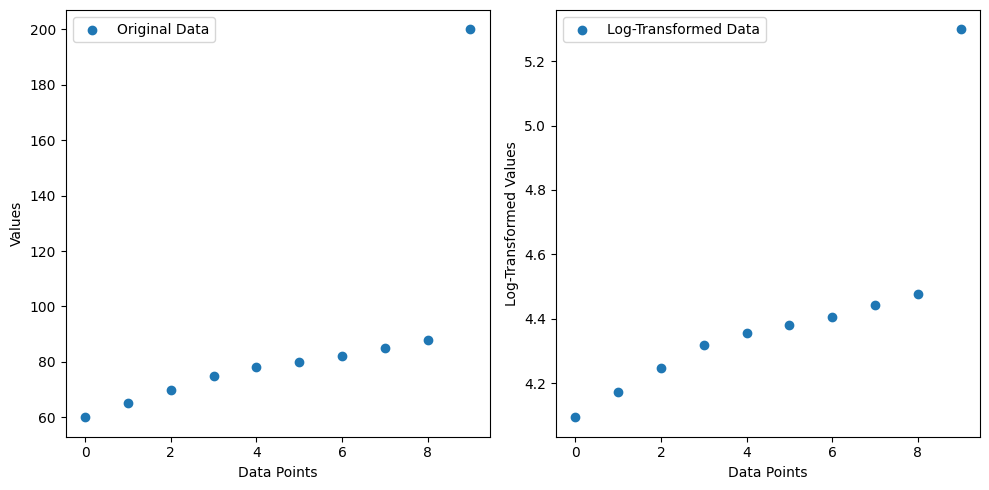

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Sample dataset with outliers
data = np.array([60, 65, 70, 75, 78, 80, 82, 85, 88, 200])

# Apply a logarithmic transformation
transformed_data = np.log(data)

# Plot the original and transformed data
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(range(len(data)), data, label='Original Data')
plt.xlabel('Data Points')
plt.ylabel('Values')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(range(len(transformed_data)), transformed_data, label='Log-Transformed Data')
plt.xlabel('Data Points')
plt.ylabel('Log-Transformed Values')
plt.legend()

plt.tight_layout()
plt.show()


3. Outlier correction using capping and flooring, also known as winsorization, involves setting a threshold beyond which outliers are replaced with the nearest non-outlier value (either the maximum or minimum non-outlier value, depending on whether the data point is above or below the threshold). This helps control the impact of extreme values on the dataset.

149.59999999999988 62.25
[ 62.25  65.    70.    75.    78.    80.    82.    85.    88.   149.6 ]


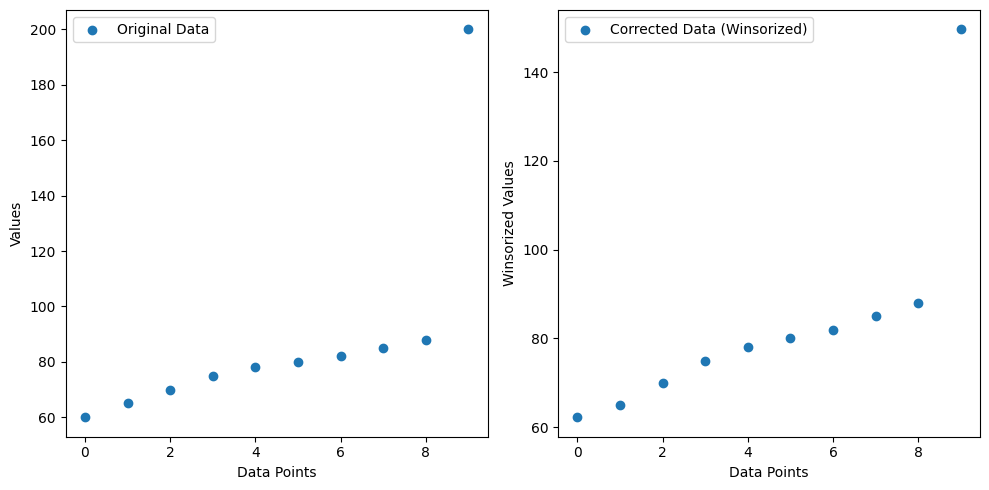

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Sample dataset with outliers
data = np.array([60, 65, 70, 75, 78, 80, 82, 85, 88, 200])

# Set the capping and flooring thresholds (e.g., using the 95th and 5th percentiles)
percentile95 = np.percentile(data, 95)
percentile5 = np.percentile(data, 5)

print(percentile95,percentile5)

# Apply capping and flooring
capped_data = np.where(data > percentile95, percentile95, data)
floored_data = np.where(data < percentile5, percentile5, capped_data)

print(floored_data)

# Plot the original and corrected data
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(range(len(data)), data, label='Original Data')
plt.xlabel('Data Points')
plt.ylabel('Values')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(range(len(floored_data)), floored_data, label='Corrected Data (Winsorized)')
plt.xlabel('Data Points')
plt.ylabel('Winsorized Values')
plt.legend()

plt.tight_layout()
plt.show()


4. Outlier correction with imputation involves identifying and correcting outliers in a dataset by imputing or replacing them with appropriate values. One common approach is to replace outliers with the mean or median value of the non-outlier data points. This method helps correct outliers while preserving the overall characteristics of the data.

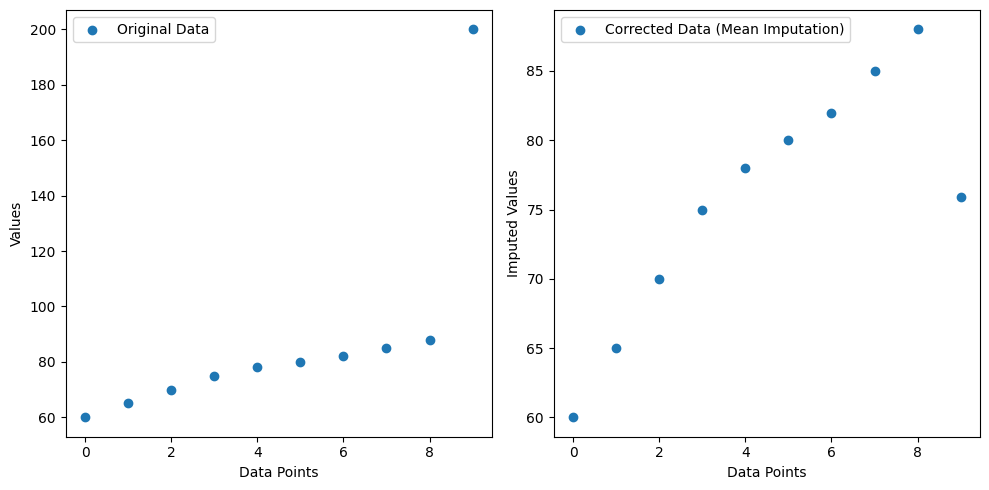

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Sample dataset with outliers
data = np.array([60, 65, 70, 75, 78, 80, 82, 85, 88, 200])

# Calculate the mean of the non-outlier values (you can use a different imputation method)
non_outlier_mean = np.mean(data[data < 200])  # Excluding the extreme outlier

# Impute the outlier value with the non-outlier mean
corrected_data = np.where(data >= 200, non_outlier_mean, data)

# Plot the original and corrected data
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(range(len(data)), data, label='Original Data')
plt.xlabel('Data Points')
plt.ylabel('Values')
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(range(len(corrected_data)), corrected_data, label='Corrected Data (Mean Imputation)')
plt.xlabel('Data Points')
plt.ylabel('Imputed Values')
plt.legend()

plt.tight_layout()
plt.show()


**Meaningful data transformation**

Meaningful data transformation refers to the process of converting raw or original data into a new representation that better aligns with the objectives of your analysis, simplifies the data, enhances its interpretability, or prepares it for further analysis. The goal is to make the data more understandable, insightful, or suitable for specific modeling techniques or tasks. Meaningful data transformation is an essential step in data preprocessing, and the choice of transformation depends on the characteristics of the data and the specific goals of your analysis or modeling. The goal is to ensure that the transformed data is more amenable to the intended analysis and retains the essential information needed to make informed decisions.

1. Logarithmic Transformation:

  Purpose: Reduce the impact of extreme values, stabilize variances, and make data more symmetric.

  When to Use: When the data is right-skewed or contains values that span multiple orders of magnitude (e.g., income, population).

2. Normalization (Min-Max Scaling):

  Purpose: Rescale data to a common range (usually [0, 1]) to ensure that different features or variables are on the same scale.

  When to Use: When the magnitude of variables varies, and you want to prevent certain features from dominating others in a model

In [ ]:
import numpy as np

# Sample dataset
data = np.array([10, 20, 30, 40, 50])

# Define the minimum and maximum values for scaling
min_val = data.min()
max_val = data.max()

# Min-Max scaling formula
scaled_data = (data - min_val) / (max_val - min_val)

# Print the original and scaled data
print("Original Data:", data)
print("Scaled Data (Min-Max Scaling):", scaled_data)

Original Data: [10 20 30 40 50]
Scaled Data (Min-Max Scaling): [0.   0.25 0.5  0.75 1.  ]


3. Standardization (Z-Score Scaling):

  Purpose: Transform data to have a mean of 0 and standard deviation of 1, making it suitable for algorithms that assume normally distributed data.
  
  When to Use: When you want to center and standardize the data for techniques like principal component analysis (PCA) or when dealing with certain statistical models.

In [ ]:
import numpy as np

# Sample dataset
data = np.array([10, 20, 30, 40, 50])

# Calculate the mean and standard deviation
mean = data.mean()
std_dev = data.std()

# Z-score scaling formula
z_score_scaled_data = (data - mean) / std_dev

# Print the original and scaled data
print("Original Data:", data)
print("Z-Score Scaled Data:", z_score_scaled_data)

Original Data: [10 20 30 40 50]
Z-Score Scaled Data: [-1.41421356 -0.70710678  0.          0.70710678  1.41421356]


4. Categorical Encoding (One-Hot Encoding, Label Encoding):

  Purpose: Convert categorical variables into numerical representations that can be used in machine learning models.

  When to Use: When dealing with categorical data, such as class labels or nominal variables.

5. Aggregation and Grouping:

  Purpose: Combine and summarize data at a higher level of granularity to generate more compact, informative datasets.
  
  When to Use: When you need to analyze data at different levels of detail, such as monthly sales aggregated from daily sales.

In [ ]:
import pandas as pd

# Sample employee dataset
data = {
    'EmployeeID': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve', 'Frank', 'Grace', 'Hannah', 'Ivy', 'Jack'],
    'Department': ['HR', 'Finance', 'HR', 'IT', 'Finance', 'IT', 'IT', 'HR', 'Finance', 'IT'],
    'Salary': [50000, 60000, 55000, 75000, 65000, 72000, 78000, 52000, 61000, 73000]
}

df = pd.DataFrame(data)


#print(list(df.groupby('Department')))

# Group by 'Department' and calculate the average salary
department_avg_salary = df.groupby('Department')['Salary'].mean()

# Print the result
print(department_avg_salary)

Department
Finance    62000.000000
HR         52333.333333
IT         74500.000000
Name: Salary, dtype: float64


6. Binning and Discretization:

  Purpose: Divide continuous variables into bins or categories to simplify analysis, identify patterns, or create ordinal data.

  When to Use: When continuous data needs to be converted into categorical form (e.g., age groups, income brackets).

In [ ]:
import pandas as pd

# Sample dataset with ages
data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve', 'Frank', 'Grace', 'Hannah', 'Ivy', 'Jack'],
    'Age': [25, 32, 19, 44, 36, 28, 53, 22, 29, 40]
}

df = pd.DataFrame(data)

# Define age bins
age_bins = [0, 18, 30, 40, 50, 100]  # Define age ranges

# Create labels for age bins
age_labels = ['0-18', '19-30', '31-40', '41-50', '51+']

# Bin the ages into the specified age ranges
df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)

# Print the result
print(df[['Name', 'Age', 'AgeGroup']])


      Name  Age AgeGroup
0    Alice   25    19-30
1      Bob   32    31-40
2  Charlie   19    19-30
3    David   44    41-50
4      Eve   36    31-40
5    Frank   28    19-30
6    Grace   53      51+
7   Hannah   22    19-30
8      Ivy   29    19-30
9     Jack   40    41-50


7. Principal Component Analysis (PCA):

  Purpose: Reduce the dimensionality of the data while retaining as much variance as possible.

  When to Use: When dealing with high-dimensional data or when simplifying feature spaces for visualization or modeling.

Explained Variance Ratio: [1.0000000e+00 1.4791142e-32]


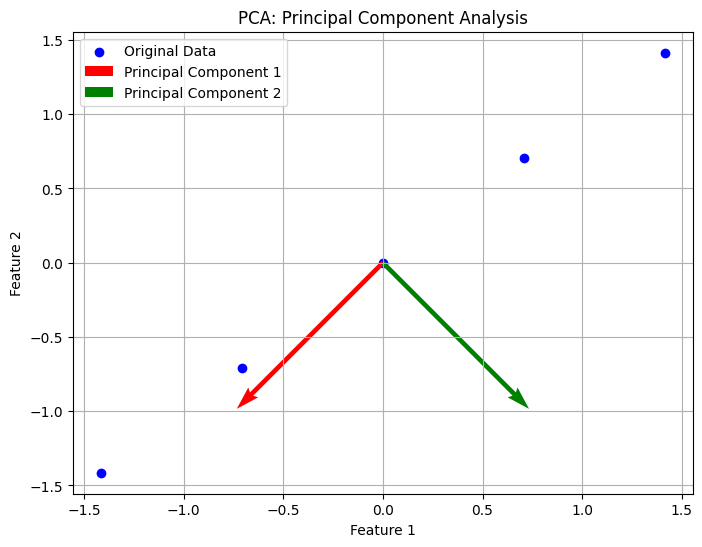

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Sample dataset with two features (variables)
data = np.array([[1, 2], [2, 3], [3, 4], [4, 5], [5, 6]])

# Standardize the data (optional but recommended for PCA)
scaler = StandardScaler()
data_standardized = scaler.fit_transform(data)

# Apply PCA with two principal components (you can specify the number of components)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(data_standardized)

# Explained variance ratio (proportion of total variance explained by each PC)
explained_variance_ratio = pca.explained_variance_ratio_

# Print the explained variance ratio
print("Explained Variance Ratio:", explained_variance_ratio)

# Plot the data and principal components
plt.figure(figsize=(8, 6))
plt.scatter(data_standardized[:, 0], data_standardized[:, 1], label='Original Data', color='blue')
plt.quiver(0, 0, pca.components_[0, 0], pca.components_[0, 1], scale=3, color='red', label='Principal Component 1')
plt.quiver(0, 0, pca.components_[1, 0], pca.components_[1, 1], scale=3, color='green', label='Principal Component 2')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.title('PCA: Principal Component Analysis')
plt.show()

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


# Sample dataset with four features (variables)
data = np.array([[1, 2, 3, 4], [2, 3, 4, 5], [3, 4, 5, 6], [4, 5, 6, 7], [5, 6, 7, 8]])

# Standardize the data (optional but recommended for PCA)
scaler = StandardScaler()
data_standardized = scaler.fit_transform(data)

# Apply PCA to reduce to two dimensions
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(data_standardized)

# Original data shape
print("Original Data Shape:", data.shape)

# Reduced data shape
print("Reduced Data Shape:", reduced_data.shape)

# Print the original and reduced data
print("Original Data:")
print(data)
print("Reduced Data (2D):")
print(reduced_data)


Original Data Shape: (5, 4)
Reduced Data Shape: (5, 2)
Original Data:
[[1 2 3 4]
 [2 3 4 5]
 [3 4 5 6]
 [4 5 6 7]
 [5 6 7 8]]
Reduced Data (2D):
[[ 2.82842712e+00  3.64856517e-16]
 [ 1.41421356e+00 -1.21618839e-16]
 [-0.00000000e+00  0.00000000e+00]
 [-1.41421356e+00  1.21618839e-16]
 [-2.82842712e+00  2.43237678e-16]]
